In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
np.set_printoptions(precision=3, suppress=True)

In [2]:
def compute_homography(src_pts, dst_pts):
    A = np.zeros((8, 8))
    b = np.zeros(8)
    for i in range(4):
        x, y = src_pts[i]
        xp, yp = dst_pts[i]
        A[2 * i]     = [x, y, 1, 0, 0, 0, -x * xp, -y * xp]
        A[2 * i + 1] = [0, 0, 0, x, y, 1, -x * yp, -y * yp]
        b[2 * i] = xp
        b[2 * i + 1] = yp
    h = np.linalg.solve(A, b)
    H = np.array([[h[0], h[1], h[2]],
                  [h[3], h[4], h[5]],
                  [h[6], h[7], 1.0]])
    return H

def composite(bg, layer, mask):
    out = bg.copy()
    out[mask > 0] = layer[mask > 0]
    return out

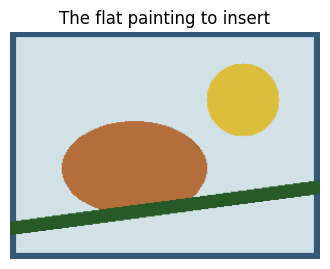

In [3]:
def make_painting(w=300, h=220):
    img = np.full((h, w, 3), (230, 225, 210), dtype=np.uint8)
    cv2.rectangle(img, (0, 0), (w - 1, h - 1), (120, 90, 50), 10)
    cv2.ellipse(img, (int(w * 0.4), int(h * 0.6)), (70, 45), 0, 0, 360, (60, 110, 180), -1)
    cv2.circle(img, (int(w * 0.75), int(h * 0.3)), 35, (60, 190, 220), -1)
    cv2.line(img, (0, h - 30), (w, h - 70), (40, 90, 40), 12)
    return img

painting = make_painting()
cv2.imwrite('data_painting.png', painting)
plt.figure(figsize=(4, 3))
plt.imshow(cv2.cvtColor(painting, cv2.COLOR_BGR2RGB))
plt.title('The flat painting to insert')
plt.axis('off')
plt.savefig('output/00_painting.png', bbox_inches='tight', dpi=150)
plt.show()

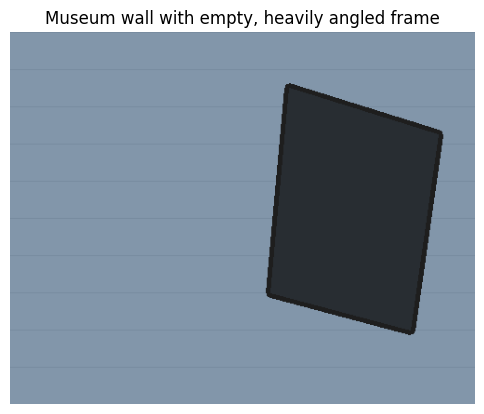

In [4]:
wall_w, wall_h = 500, 400
wall = np.full((wall_h, wall_w, 3), (170, 150, 130), dtype=np.uint8)
for y in range(0, wall_h, 40):
    cv2.line(wall, (0, y), (wall_w, y), (160, 140, 120), 1)

frame_corners = np.array([
    [300, 60],
    [460, 110],
    [430, 320],
    [280, 280]
], dtype=np.float32)

cv2.polylines(wall, [frame_corners.astype(int)], True, (30, 30, 30), 10)
cv2.fillConvexPoly(wall, frame_corners.astype(int), (50, 45, 40))

plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(wall, cv2.COLOR_BGR2RGB))
plt.title('Museum wall with empty, heavily angled frame')
plt.axis('off')
plt.savefig('output/01_wall_empty_frame.png', bbox_inches='tight', dpi=150)
plt.show()

Linear scale matrix S =
 [[0.6 0. ]
 [0.  0.6]]


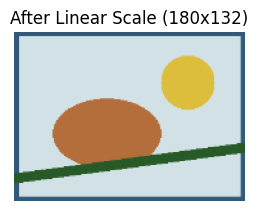

In [5]:
ph, pw = painting.shape[:2]

scale_factor = 0.6
S = np.array([
    [scale_factor, 0],
    [0, scale_factor]
])
print('Linear scale matrix S =\n', S)

scaled_w, scaled_h = int(pw * scale_factor), int(ph * scale_factor)
scaled_painting = cv2.warpAffine(painting, np.hstack([S, [[0], [0]]]), (scaled_w, scaled_h))

plt.figure(figsize=(3, 2.2))
plt.imshow(cv2.cvtColor(scaled_painting, cv2.COLOR_BGR2RGB))
plt.title(f'After Linear Scale ({scaled_w}x{scaled_h})')
plt.axis('off')
plt.savefig('output/02_scaled.png', bbox_inches='tight', dpi=150)
plt.show()

Rigid rotation matrix R =
 [[ 0.978 -0.208  0.   ]
 [ 0.208  0.978  0.   ]
 [ 0.     0.     1.   ]]
Combined rigid matrix M_rigid = T @ R @ T_to_origin =
 [[  0.978  -0.208 293.189]
 [  0.208   0.978 109.23 ]
 [  0.      0.      1.   ]]


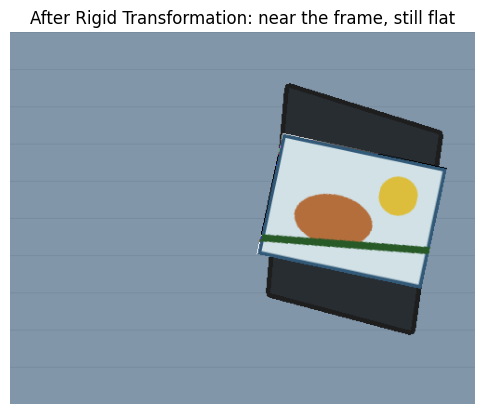

In [6]:
frame_centroid = frame_corners.mean(axis=0)
scaled_center = np.array([scaled_w / 2, scaled_h / 2])
rigid_angle_deg = 12.0

theta = np.deg2rad(rigid_angle_deg)
R = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0, 0, 1]
])
print('Rigid rotation matrix R =\n', R)

T_to_origin = np.array([[1, 0, -scaled_center[0]], [0, 1, -scaled_center[1]], [0, 0, 1]])
T_to_frame = np.array([[1, 0, frame_centroid[0]], [0, 1, frame_centroid[1]], [0, 0, 1]])

M_rigid = T_to_frame @ R @ T_to_origin
print('Combined rigid matrix M_rigid = T @ R @ T_to_origin =\n', M_rigid)

near_frame = cv2.warpAffine(scaled_painting, M_rigid[:2, :], (wall_w, wall_h), borderMode=cv2.BORDER_TRANSPARENT)
mask_src = np.full((scaled_h, scaled_w), 255, dtype=np.uint8)
near_frame_mask = cv2.warpAffine(mask_src, M_rigid[:2, :], (wall_w, wall_h))

preview = composite(wall, near_frame, near_frame_mask)
plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title('After Rigid Transformation: near the frame, still flat')
plt.axis('off')
plt.savefig('output/03_near_frame.png', bbox_inches='tight', dpi=150)
plt.show()

Positioned painting corners (source for the homography):
 [[293.189 109.23 ]
 [469.255 146.654]
 [441.811 275.77 ]
 [265.745 238.346]]
Target frame corners (destination):
 [[300.  60.]
 [460. 110.]
 [430. 320.]
 [280. 280.]]
Projective matrix H =
 [[   1.039    0.226   -2.075]
 [  -0.095    2.012 -126.496]
 [   0.       0.001    1.   ]]


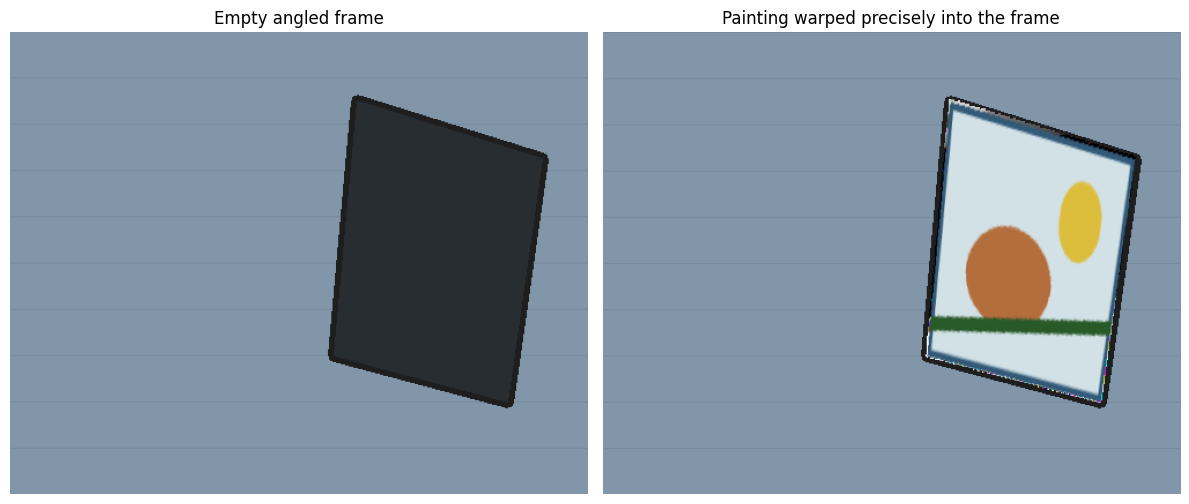

In [7]:
scaled_corners = np.array([
    [0, 0], [scaled_w, 0], [scaled_w, scaled_h], [0, scaled_h]
], dtype=np.float64)
ones = np.ones((4, 1))
positioned_corners = (M_rigid[:2, :] @ np.hstack([scaled_corners, ones]).T).T
print('Positioned painting corners (source for the homography):\n', positioned_corners)
print('Target frame corners (destination):\n', frame_corners)

H = compute_homography(positioned_corners, frame_corners)
print('Projective matrix H =\n', H)

warped_painting = cv2.warpPerspective(near_frame, H, (wall_w, wall_h), borderMode=cv2.BORDER_TRANSPARENT)
warped_mask = cv2.warpPerspective(near_frame_mask, H, (wall_w, wall_h))

forged_wall = composite(wall, warped_painting, warped_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(wall, cv2.COLOR_BGR2RGB))
axes[0].set_title('Empty angled frame')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(forged_wall, cv2.COLOR_BGR2RGB))
axes[1].set_title('Painting warped precisely into the frame')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/04_final_forgery.png', bbox_inches='tight', dpi=150)
plt.show()